# LSTM Prediksi Penjualan Harian — Versi Disederhanakan

**Pendekatan:** one-step-ahead · target `log1p(revenue)` · LSTM 1-layer · fitur kalender (anti-kebocoran)
**Pembanding:** Naive (kemarin), Mean-7, SARIMA
**Metrik:** RMSE, MAE, sMAPE, **MASE** (target: MASE < 1 → lebih baik daripada naif)

> Catatan: notebook ini belum dieksekusi karena `daily_sales.csv` perlu ada di `DATA_DIR`.
> Jalankan sel berurutan. `transactions` & `qty_sold` sengaja dibuang dari input karena tidak
> tersedia saat memprediksi masa depan (kalau dipakai = data leakage).

## SECTION 0 — Setup & Path

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

# Sesuaikan bila struktur foldermu berbeda
DATA_DIR  = '../Data'
DAILY_CSV = os.path.join(DATA_DIR, 'daily_sales.csv')
print('Setup OK. Daily CSV:', DAILY_CSV, '| ada?', os.path.exists(DAILY_CSV))

Setup OK. Daily CSV: data\daily_sales.csv | ada? True


## SECTION 1 — Konfigurasi, Metrik & Fitur (one-step, log target)

In [2]:
# ── Konfigurasi sederhana ─────────────────────────────────────────────────────
LOOK_BACK = 7      # 1 minggu hari-aktif
HORIZON   = 1      # one-step-ahead (multi-step via recursive)
UNITS     = 24
DROPOUT   = 0.1

# ── Metrik (tanpa MAPE) ───────────────────────────────────────────────────────
def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat)) / 2
    return np.mean(np.abs(y - yhat) / np.where(d == 0, 1, d)) * 100

def mase(y, yhat, naive_mae):          # naive_mae = MAE naif in-sample (train)
    return mean_absolute_error(y, yhat) / naive_mae

def report(y, yhat, naive_mae, label):
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae  = mean_absolute_error(y, yhat)
    print(f'{label:18s} RMSE: Rp {rmse:>12,.0f} | MAE: Rp {mae:>12,.0f} '
          f'| sMAPE: {smape(y,yhat):6.2f}% | MASE: {mase(y,yhat,naive_mae):.3f}')
    return {'rmse': rmse, 'mae': mae, 'smape': smape(y,yhat), 'mase': mase(y,yhat,naive_mae)}

# ── Data harian + fitur kalender (deterministik, aman untuk forecast) ─────────
df = pd.read_csv(DAILY_CSV, parse_dates=['date'])
dfa = df[df['revenue'] > 0].copy().sort_values('date').reset_index(drop=True)

dfa['rev_log']   = np.log1p(dfa['revenue'])
dfa['week_sin']  = np.sin(2*np.pi*dfa['week_of_year']/52)
dfa['week_cos']  = np.cos(2*np.pi*dfa['week_of_year']/52)
dfa['month_sin'] = np.sin(2*np.pi*dfa['month']/12)
dfa['month_cos'] = np.cos(2*np.pi*dfa['month']/12)
dfa['dow_sin']   = np.sin(2*np.pi*dfa['day_of_week']/5)
dfa['dow_cos']   = np.cos(2*np.pi*dfa['day_of_week']/5)

# transactions & qty_sold DIBUANG dari input (tidak tersedia di masa depan)
FEATURES = ['rev_log','week_sin','week_cos','month_sin','month_cos',
            'dow_sin','dow_cos','is_ramadan']

n = len(dfa)
n_tr = int(n*0.70); n_va = int(n*0.15)
df_tr, df_va, df_te = dfa.iloc[:n_tr], dfa.iloc[n_tr:n_tr+n_va], dfa.iloc[n_tr+n_va:]
print(f'Train {len(df_tr)} | Val {len(df_va)} | Test {len(df_te)} hari aktif')

Train 219 | Val 46 | Test 48 hari aktif


## SECTION 2 — Scaling & Pembentukan Sequence

In [3]:
scaler = MinMaxScaler()
tr_s = scaler.fit_transform(df_tr[FEATURES].values)   # fit HANYA train
va_s = scaler.transform(df_va[FEATURES].values)
te_s = scaler.transform(df_te[FEATURES].values)

def make_seq(arr, look_back, horizon, tcol=0):
    X, y = [], []
    for i in range(len(arr) - look_back - horizon + 1):
        X.append(arr[i:i+look_back])
        y.append(arr[i+look_back:i+look_back+horizon, tcol])
    return np.array(X), np.array(y)

X_tr, y_tr = make_seq(tr_s, LOOK_BACK, HORIZON)
X_va, y_va = make_seq(va_s, LOOK_BACK, HORIZON)
X_te, y_te = make_seq(te_s, LOOK_BACK, HORIZON)
print('X_tr', X_tr.shape, '| X_va', X_va.shape, '| X_te', X_te.shape)

# Inverse kolom rev_log (col 0) -> Rupiah
rng0, min0 = scaler.data_range_[0], scaler.data_min_[0]
def inv_rev(scaled_col0):
    return np.expm1(np.asarray(scaled_col0) * rng0 + min0)

X_tr (212, 7, 8) | X_va (39, 7, 8) | X_te (41, 7, 8)


## SECTION 3 — Model Sederhana (1-layer LSTM) & Training

In [4]:
def build_simple_lstm():
    m = Sequential([
        LSTM(UNITS, input_shape=(LOOK_BACK, len(FEATURES))),
        Dropout(DROPOUT),
        Dense(16, activation='relu'),
        Dense(HORIZON)
    ], name='lstm_simple_7lb_1h')
    m.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
    return m

cb = [EarlyStopping('val_loss', patience=20, restore_best_weights=True, verbose=1),
      ReduceLROnPlateau('val_loss', factor=0.5, patience=8, min_lr=1e-6)]

model = build_simple_lstm()
model.summary()
hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=200, batch_size=16, callbacks=cb, verbose=1)
print('Best epoch:', np.argmin(hist.history['val_loss']) + 1)   # harus > 1!

Model: "lstm_simple_7lb_1h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24)             │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.5346 - mae: 0.7095 - val_loss: 0.2373 - val_mae: 0.4414 - learning_rate: 5.0000e-04
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2713 - mae: 0.4942 - val_loss: 0.0809 - val_mae: 0.2367 - learning_rate: 5.0000e-04
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1059 - mae: 0.2919 - val_loss: 0.0472 - val_mae: 0.1902 - learning_rate: 5.0000e-04
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0417 - mae: 0.1571 - val_loss: 0.0827 - val_mae: 0.2311 - learning_rate: 5.0000e-04
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0429 - mae: 0.1463 - val_loss: 0.0794 - val_mae: 0.2312 - learning_rate: 5.0000e-04
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0372 - mae: 0.1395 - val_loss: 0.0590 - val_mae: 0.2019 - learning_rate: 5.0000e-04
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0340 - mae: 0.1282 - val_loss: 0.0504 - val_mae: 0.1876 - learni

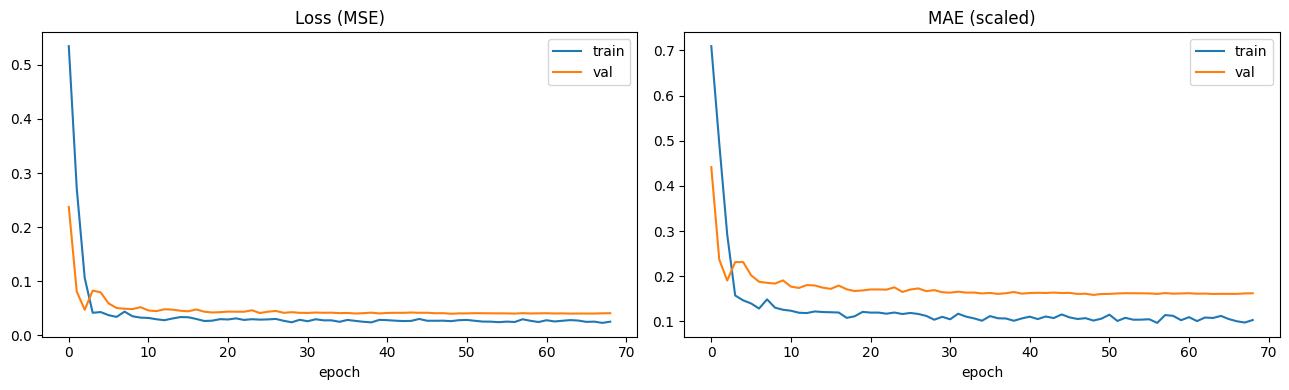

In [5]:
# Plot kurva training
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('Loss (MSE)'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist.history['mae'], label='train'); ax[1].plot(hist.history['val_mae'], label='val')
ax[1].set_title('MAE (scaled)'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

## SECTION 4 — Evaluasi LSTM + Baseline Naif

In [6]:
# Target test (Rupiah): indeks day LOOK_BACK..akhir pada split test
rev_te = df_te['revenue'].values
y_true = rev_te[LOOK_BACK:]

# Denominator MASE: MAE naif in-sample (train)
rev_tr = df_tr['revenue'].values
naive_mae = np.mean(np.abs(np.diff(rev_tr)))

# LSTM
y_lstm = inv_rev(model.predict(X_te, verbose=0).flatten())

# Baseline 1: nilai kemarin
y_naive = rev_te[LOOK_BACK-1:-1]
# Baseline 2: rata-rata 7 hari aktif terakhir
y_mean7 = np.array([rev_te[i-LOOK_BACK:i].mean() for i in range(LOOK_BACK, len(rev_te))])

print('=== Evaluasi Test (one-step-ahead) ===')
m_naive = report(y_true, y_naive, naive_mae, 'Naive (kemarin)')
m_mean7 = report(y_true, y_mean7, naive_mae, 'Mean-7')
m_lstm  = report(y_true, y_lstm,  naive_mae, 'LSTM (simpel)')

=== Evaluasi Test (one-step-ahead) ===
Naive (kemarin)    RMSE: Rp      697,253 | MAE: Rp      519,841 | sMAPE:  30.77% | MASE: 1.432
Mean-7             RMSE: Rp      791,746 | MAE: Rp      647,263 | sMAPE:  36.25% | MASE: 1.784
LSTM (simpel)      RMSE: Rp    1,358,408 | MAE: Rp    1,214,076 | sMAPE:  71.49% | MASE: 3.345


## SECTION 5 — Pembanding SARIMA (rolling one-step)

In [7]:
# !pip install statsmodels   # jalankan sekali bila belum ada
from statsmodels.tsa.statespace.sarimax import SARIMAX

hist_log = list(np.log1p(np.concatenate([rev_tr, df_va['revenue'].values])))
res = SARIMAX(hist_log, order=(1,1,1), seasonal_order=(1,0,0,5),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

sarima_pred = []
for actual in rev_te:                       # rolling one-step sepanjang test
    sarima_pred.append(np.expm1(res.forecast(1)[0]))
    res = res.append([np.log1p(actual)], refit=False)

y_sarima = np.array(sarima_pred)[LOOK_BACK:]   # samakan alignment dgn LSTM
m_sarima = report(y_true, y_sarima, naive_mae, 'SARIMA')

SARIMA             RMSE: Rp      751,408 | MAE: Rp      586,083 | sMAPE:  33.80% | MASE: 1.615


## SECTION 6 — Tabel Perbandingan Final (untuk Bab IV)

          Model         RMSE          MAE    sMAPE%     MASE
Naive (kemarin) 6.972527e+05 5.198415e+05 30.771030 1.432459
         Mean-7 7.917455e+05 6.472631e+05 36.249040 1.783578
         SARIMA 7.514084e+05 5.860827e+05 33.803188 1.614992
           LSTM 1.358408e+06 1.214076e+06 71.491845 3.345470

MASE < 1  -> model lebih baik daripada prediksi naif.


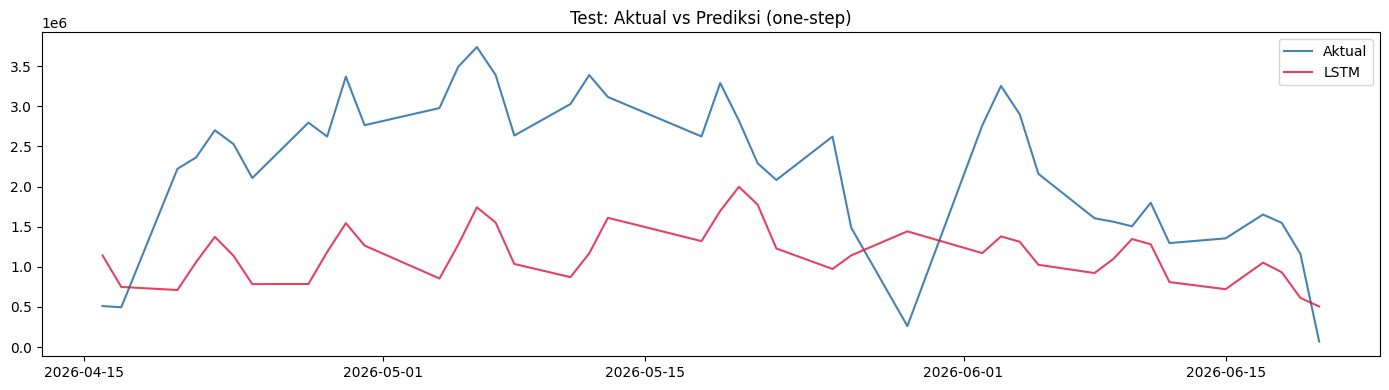

In [8]:
tbl = pd.DataFrame({
    'Model'  : ['Naive (kemarin)','Mean-7','SARIMA','LSTM'],
    'RMSE'   : [m_naive['rmse'], m_mean7['rmse'], m_sarima['rmse'], m_lstm['rmse']],
    'MAE'    : [m_naive['mae'],  m_mean7['mae'],  m_sarima['mae'],  m_lstm['mae']],
    'sMAPE%' : [m_naive['smape'],m_mean7['smape'],m_sarima['smape'],m_lstm['smape']],
    'MASE'   : [m_naive['mase'], m_mean7['mase'], m_sarima['mase'], m_lstm['mase']],
})
print(tbl.to_string(index=False))
print('\nMASE < 1  -> model lebih baik daripada prediksi naif.')

# Visualisasi actual vs predicted (LSTM) di test
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df_te['date'].values[LOOK_BACK:], y_true, label='Aktual', color='steelblue')
ax.plot(df_te['date'].values[LOOK_BACK:], y_lstm, label='LSTM',  color='crimson', alpha=.8)
ax.set_title('Test: Aktual vs Prediksi (one-step)'); ax.legend(); plt.tight_layout(); plt.show()

## SECTION 7 — Forecast 7 Hari Aktif ke Depan (recursive)

In [9]:
def forecast_recursive(model, dfa, scaler, features, look_back, n_steps):
    window = scaler.transform(dfa.tail(look_back)[features].values)  # (L, n_feat)
    last_date = pd.Timestamp(dfa['date'].max())
    rows, d = [], last_date
    while len(rows) < n_steps:
        d += pd.Timedelta(days=1)
        if d.weekday() >= 5 or d.month in [1, 7]:      # skip weekend & libur semester
            continue
        pred_scaled = model.predict(window[np.newaxis], verbose=0)[0, 0]
        rev_log = pred_scaled * rng0 + min0
        revenue = np.expm1(rev_log)
        woy = d.isocalendar().week
        raw = [rev_log,
               np.sin(2*np.pi*woy/52), np.cos(2*np.pi*woy/52),
               np.sin(2*np.pi*d.month/12), np.cos(2*np.pi*d.month/12),
               np.sin(2*np.pi*d.weekday()/5), np.cos(2*np.pi*d.weekday()/5),
               0]                                       # is_ramadan future = 0
        nxt = scaler.transform([raw])[0]
        window = np.vstack([window[1:], nxt])
        rows.append({'tanggal': d.date(), 'hari': d.strftime('%A'),
                     'prediksi_revenue': int(round(revenue))})
    return pd.DataFrame(rows)

fc = forecast_recursive(model, dfa, scaler, FEATURES, LOOK_BACK, 7)
print('=== Prediksi 7 Hari Aktif ke Depan (recursive) ===')
print(fc.to_string(index=False))
print(f'\nTotal: Rp {fc.prediksi_revenue.sum():,} | Rata-rata: Rp {fc.prediksi_revenue.mean():,.0f}')

=== Prediksi 7 Hari Aktif ke Depan (recursive) ===
   tanggal      hari  prediksi_revenue
2026-06-22    Monday            658088
2026-06-23   Tuesday           1056832
2026-06-24 Wednesday           1417981
2026-06-25  Thursday           1157754
2026-06-26    Friday            794542
2026-06-29    Monday            729886
2026-06-30   Tuesday            958879

Total: Rp 6,773,962 | Rata-rata: Rp 967,709
